In [1]:
# Cell 0 — Setup
!pip -q install scipy seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)
np.set_printoptions(suppress=True, precision=3)

print("✅ Ready — NumPy:", np.__version__)


✅ Ready — NumPy: 2.0.2


In [2]:
# Cell 1 — Upload & load the Airplane Crashes dataset from your computer
from google.colab import files

print("📤 Upload the CSV (e.g., Airplane_Crashes_and_Fatalities_*.csv)")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Try encodings robustly
last_err = None
for enc in (None, "utf-8", "latin-1", "cp1252"):
    try:
        df_raw = pd.read_csv(filename, encoding=enc) if enc else pd.read_csv(filename)
        break
    except Exception as e:
        last_err = e
else:
    raise last_err

print("✅ Loaded:", filename, "shape:", df_raw.shape)
df_raw.head()


📤 Upload the CSV (e.g., Airplane_Crashes_and_Fatalities_*.csv)


Saving Airplane_Crashes_and_Fatalities_Since_1908_t0_2023.csv to Airplane_Crashes_and_Fatalities_Since_1908_t0_2023.csv
✅ Loaded: Airplane_Crashes_and_Fatalities_Since_1908_t0_2023.csv shape: (4998, 17)


,Date,Time,Location,Operator,Flight #,Route,AC Type,Registration,cn/ln,Aboard,Aboard Passangers,Aboard Crew,Fatalities,Fatalities Passangers,Fatalities Crew,Ground,Summary
0,9/17/1908,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,1.0,1.0,1.0,1.0,0.0,0.0,"During a demonstration flight, a U.S. Army fly..."
1,9/7/1909,NaN,"Juvisy-sur-Orge, France",NaN,NaN,Air show,Wright Byplane,SC1,NaN,1.0,0.0,1.0,1.0,0.0,0.0,0.0,Eugene Lefebvre was the first pilot to ever be...
2,7/12/1912,6:30,"Atlantic City, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,0.0,5.0,5.0,0.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...
3,8/6/1913,NaN,"Victoria, British Columbia, Canada",Private,NaN,NaN,Curtiss seaplane,NaN,NaN,1.0,0.0,1.0,1.0,0.0,1.0,0.0,The first fatal airplane accident in Canada oc...
4,9/9/1913,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,NaN,NaN,14.0,NaN,NaN,0.0,The airship flew into a thunderstorm and encou...


In [3]:
# Cell 2 — Cleaning & schema normalization
df = df_raw.copy()
df.columns = (
    df.columns.str.strip()
              .str.lower()
              .str.replace(r"[^0-9a-zA-Z]+", "_", regex=True)
              .str.replace(r"_+", "_", regex=True)
              .str.strip("_")
)

# Common column name variants across versions of the dataset
name_map = {
    "date":           ["date"],
    "time":           ["time"],
    "location":       ["location"],
    "operator":       ["operator", "airline"],
    "type":           ["type", "aircraft_type"],
    "aboard":         ["aboard", "aboard_total", "aboard_"],
    "fatalities":     ["fatalities", "fatalities_"],
    "ground":         ["ground"]
}

def col(std):
    for c in name_map.get(std, []):
        if c in df.columns:
            return c
    return None

# Parse date
date_col = col("date")
if date_col is None:
    raise ValueError("No 'Date' column found after normalization.")
df["date_parsed"] = pd.to_datetime(df[date_col], errors="coerce", dayfirst=False, infer_datetime_format=True)

# Basic numerics
for cstd in ["aboard", "fatalities", "ground"]:
    c = col(cstd)
    if c and c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Survivors & survival rate
aboard_c = col("aboard")
fatal_c  = col("fatalities")
if aboard_c and fatal_c:
    df["survivors"] = df[aboard_c] - df[fatal_c]
    df["survival_rate"] = np.where(df[aboard_c] > 0, df["survivors"] / df[aboard_c], np.nan)

# Year / Month / Decade
df["year"]  = df["date_parsed"].dt.year
df["month"] = df["date_parsed"].dt.month
df["decade"] = (df["year"] // 10) * 10

# Country from location (best-effort: last token after comma)
loc_c = col("location")
if loc_c and loc_c in df.columns:
    df["country_guess"] = (
        df[loc_c].astype(str)
                 .str.split(",")
                 .str[-1]
                 .str.strip()
                 .replace("", np.nan)
    )

# Keep useful view
keep = {
    "date": date_col,
    "time": col("time"),
    "location": loc_c,
    "country_guess": "country_guess",
    "operator": col("operator"),
    "type": col("type"),
    "aboard": aboard_c,
    "fatalities": fatal_c,
    "ground": col("ground"),
    "survivors": "survivors",
    "survival_rate": "survival_rate",
    "year": "year",
    "month": "month",
    "decade": "decade",
}
cols = [v for v in keep.values() if v is not None]
g = df[cols].copy()
print("✅ Cleaned shape:", g.shape)
g.head()


✅ Cleaned shape: (4998, 13)


/tmp/ipython-input-692489780.py:33: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df["date_parsed"] = pd.to_datetime(df[date_col], errors="coerce", dayfirst=False, infer_datetime_format=True)


,date,time,location,country_guess,operator,aboard,fatalities,ground,survivors,survival_rate,year,month,decade
0,9/17/1908,17:18,"Fort Myer, Virginia",Virginia,Military - U.S. Army,2.0,1.0,0.0,1.0,0.5,1908,9,1900
1,9/7/1909,NaN,"Juvisy-sur-Orge, France",France,NaN,1.0,1.0,0.0,0.0,0.0,1909,9,1900
2,7/12/1912,6:30,"Atlantic City, New Jersey",New Jersey,Military - U.S. Navy,5.0,5.0,0.0,0.0,0.0,1912,7,1910
3,8/6/1913,NaN,"Victoria, British Columbia, Canada",Canada,Private,1.0,1.0,0.0,0.0,0.0,1913,8,1910
4,9/9/1913,18:30,Over the North Sea,Over the North Sea,Military - German Navy,20.0,14.0,0.0,6.0,0.3,1913,9,1910


In [4]:
# Cell 3 — Missing values & quick descriptive stats
print("Missing per column:")
display(g.isna().sum().sort_values(ascending=False))

num_cols = [c for c in ["aboard","fatalities","ground","survivors","survival_rate"] if c in g.columns]
print("\nNumeric summary:")
display(g[num_cols].describe().T.round(3))


Missing per column:


,0
time,1512
ground,42
survival_rate,23
aboard,18
survivors,18
operator,10
fatalities,8
location,4
date,0
country_guess,0



Numeric summary:


,count,mean,std,min,25%,50%,75%,max
aboard,4980.0,31.196,45.535,0.0,7.0,16.0,35.00,644.0
fatalities,4990.0,22.374,35.062,0.0,4.0,11.0,25.00,583.0
ground,4956.0,1.719,55.540,0.0,0.0,0.0,0.00,2750.0
survivors,4980.0,8.794,30.653,0.0,0.0,0.0,3.00,516.0
survival_rate,4975.0,0.181,0.312,0.0,0.0,0.0,0.25,1.0


In [5]:
# Cell 4 — EDA: totals & rates
total_crashes = len(g)
total_with_fat = g["fatalities"].notna().sum() if "fatalities" in g.columns else np.nan
total_fatalities = g["fatalities"].sum(skipna=True) if "fatalities" in g.columns else np.nan
overall_survival = g["survival_rate"].mean(skipna=True) if "survival_rate" in g.columns else np.nan

print(f"Total crashes (rows): {total_crashes:,}")
print(f"Rows with fatalities value: {total_with_fat:,}")
print(f"Total fatalities (sum): {int(total_fatalities) if pd.notna(total_fatalities) else 'N/A'}")
print(f"Average survival rate (mean across rows): {overall_survival:.3f}")

# Yearly crashes time series (count of records with valid date)
yearly = g.dropna(subset=["year"]).groupby("year").size().rename("crashes")
display(yearly.tail(10))


Total crashes (rows): 4,998
Rows with fatalities value: 4,990
Total fatalities (sum): 111644
Average survival rate (mean across rows): 0.181


,crashes
year,
2014,23
2015,18
2016,23
2017,15
2018,16
2019,13
2020,8
2021,9
2022,6


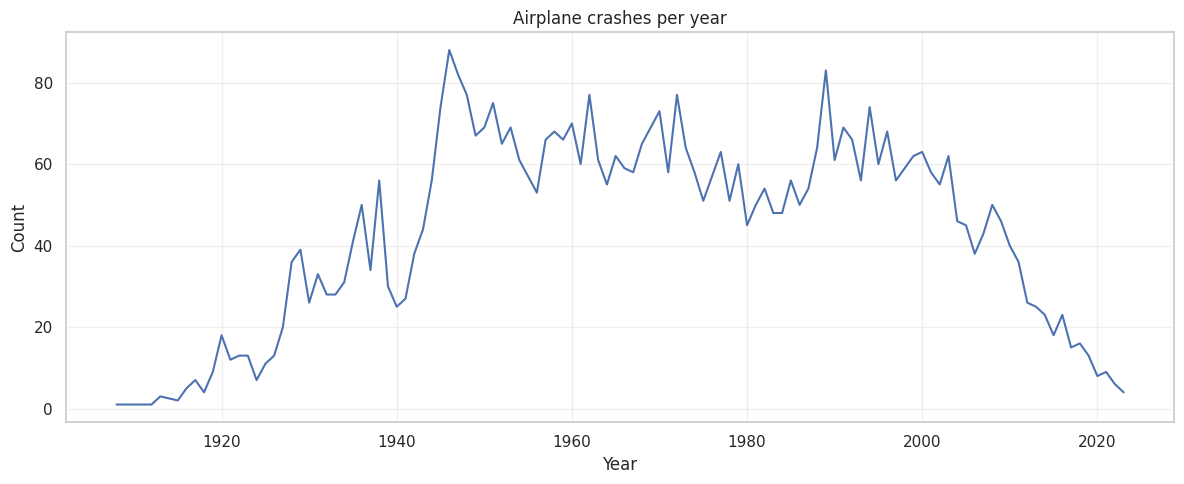

In [6]:
# Cell 5 — Time series: crashes per year
plt.figure(figsize=(12,5))
plt.plot(yearly.index, yearly.values, linewidth=1.5)
plt.title("Airplane crashes per year")
plt.xlabel("Year"); plt.ylabel("Count")
plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


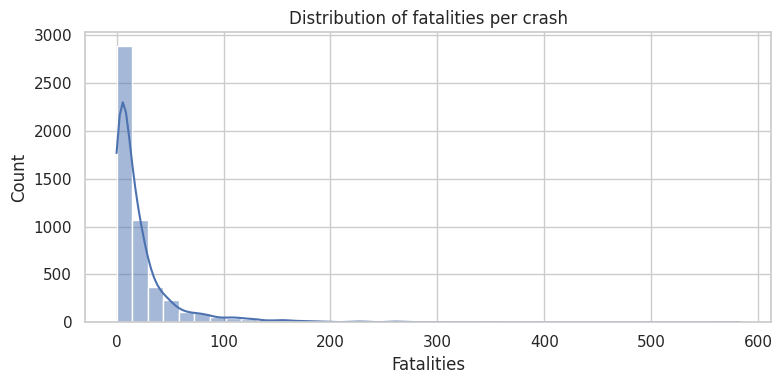

In [7]:
# Cell 6 — Distribution of fatalities per crash
if "fatalities" in g.columns:
    plt.figure(figsize=(8,4))
    sns.histplot(g["fatalities"].dropna(), bins=40, kde=True)
    plt.title("Distribution of fatalities per crash")
    plt.xlabel("Fatalities"); plt.ylabel("Count")
    plt.tight_layout(); plt.show()
else:
    print("No 'fatalities' column available.")


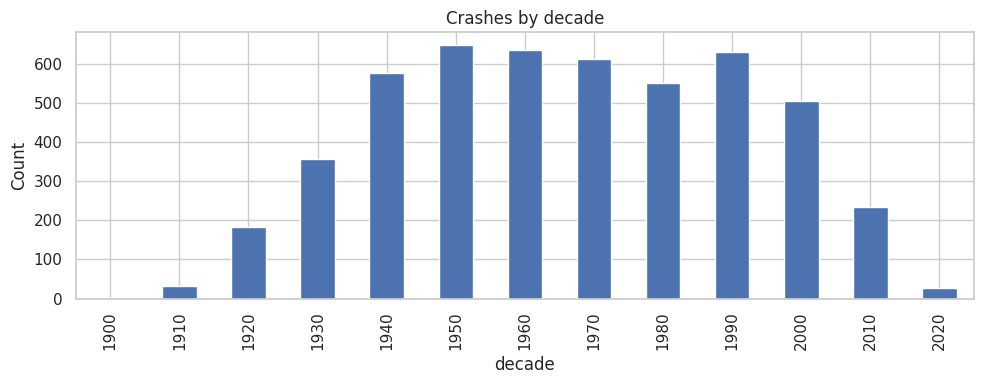

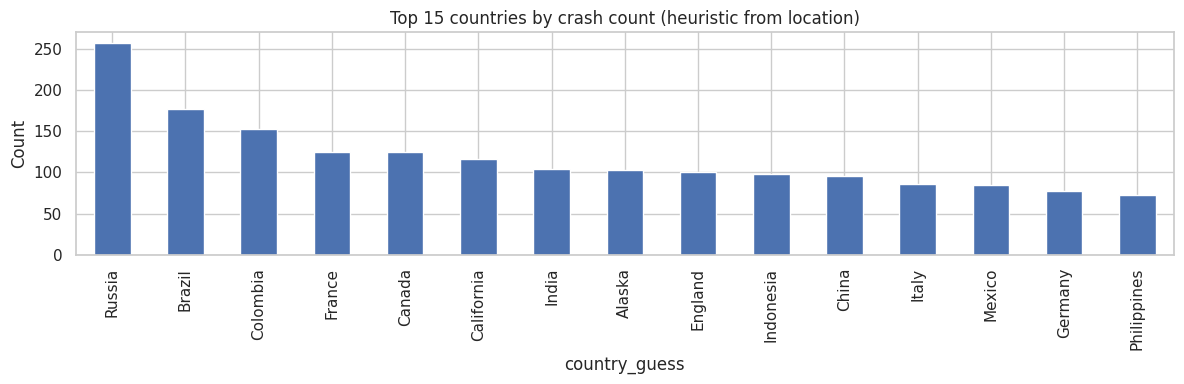

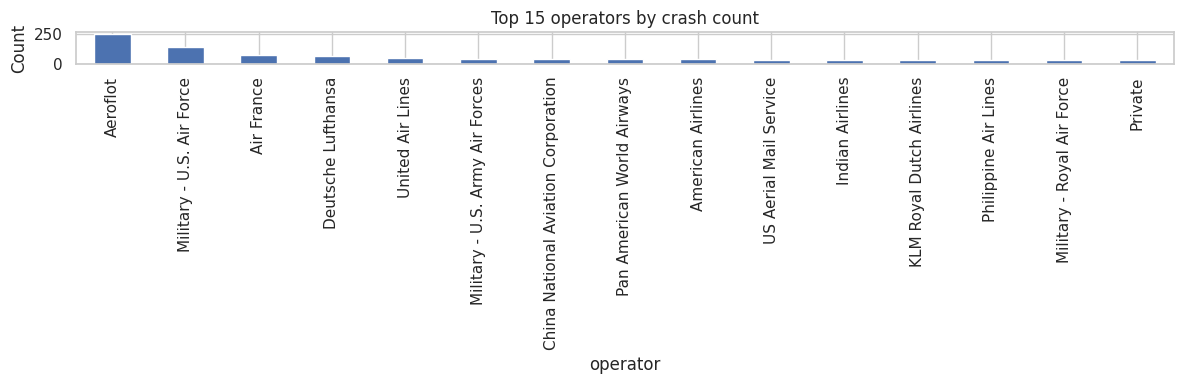

In [8]:
# Cell 7 — Crashes by decade; top countries/operators
if "decade" in g.columns:
    dec_counts = g.dropna(subset=["decade"]).groupby("decade").size()
    plt.figure(figsize=(10,4))
    dec_counts.plot(kind="bar")
    plt.title("Crashes by decade"); plt.ylabel("Count")
    plt.tight_layout(); plt.show()

# Top 15 countries (best-effort)
if "country_guess" in g.columns:
    top_countries = g["country_guess"].value_counts().head(15)
    plt.figure(figsize=(12,4))
    top_countries.plot(kind="bar")
    plt.title("Top 15 countries by crash count (heuristic from location)")
    plt.ylabel("Count")
    plt.tight_layout(); plt.show()

# Top operators with at least N records
if "operator" in g.columns:
    top_ops = g["operator"].value_counts().head(15)
    plt.figure(figsize=(12,4))
    top_ops.plot(kind="bar")
    plt.title("Top 15 operators by crash count")
    plt.ylabel("Count")
    plt.tight_layout(); plt.show()


In [9]:
# Cell 8 — Hypothesis test: do mean fatalities differ between two decades? (Welch's t-test)
if {"fatalities","decade"} <= set(g.columns):
    dec_groups = g.dropna(subset=["decade","fatalities"])
    counts = dec_groups.groupby("decade").size().sort_values(ascending=False)
    if len(counts) >= 2:
        d1, d2 = counts.index[:2].tolist()  # two most populated decades
        a = dec_groups.loc[dec_groups["decade"]==d1, "fatalities"].dropna().values
        b = dec_groups.loc[dec_groups["decade"]==d2, "fatalities"].dropna().values
        t, p = stats.ttest_ind(a, b, equal_var=False)
        print(f"Compare mean fatalities per crash: {int(d1)}s (n={len(a)}) vs {int(d2)}s (n={len(b)})")
        print(f"Welch t-stat: {t:.3f} | p-value: {p:.3e}")
        if p < 0.05:
            print("➡️ Significant difference at α=0.05.")
        else:
            print("➡️ No significant difference at α=0.05.")
    else:
        print("Not enough decades with data for comparison.")
else:
    print("Columns 'fatalities' and/or 'decade' missing.")


Compare mean fatalities per crash: 1950s (n=648) vs 1960s (n=636)
Welch t-stat: -6.526 | p-value: 1.040e-10
➡️ Significant difference at α=0.05.


,crashes,avg_fatalities,avg_survival_rate
operator,,,
Air India,10,82.700,0.106
Korean Airlines,10,71.200,0.559
Turkish Airlines (THY),13,68.462,0.096
China Airlines (Taiwan),14,60.500,0.254
Pakistan International Airlines,16,46.438,0.159
Trans World Airlines,17,46.118,0.340
Military - Russian Air Force,14,42.571,0.023
Iberia Airlines,12,40.167,0.117
AVIANCA,24,39.208,0.076


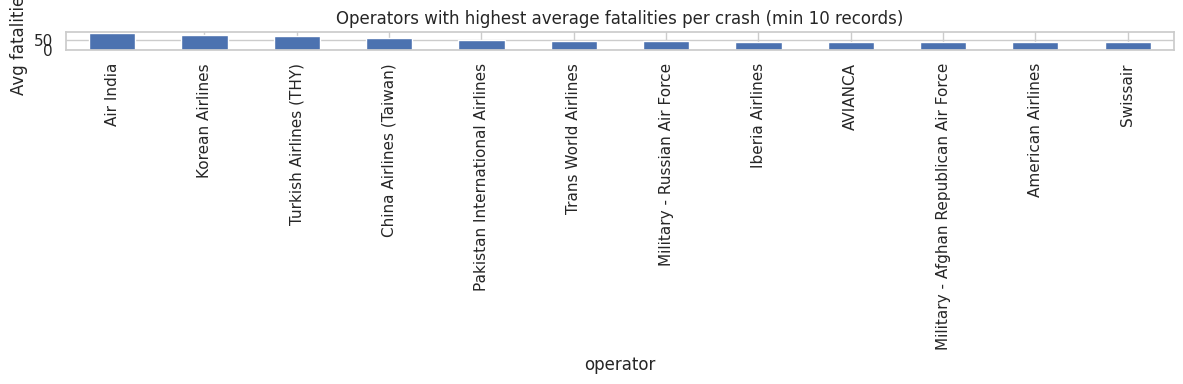

In [10]:
# Cell 9 — Average fatalities and survival rate by operator (min 10 records)
if {"operator","fatalities","aboard","survival_rate"} <= set(g.columns):
    op_stats = (g.dropna(subset=["operator"])
                  .groupby("operator")
                  .agg(
                      crashes=("operator","size"),
                      avg_fatalities=("fatalities","mean"),
                      avg_survival_rate=("survival_rate","mean")
                  )
                  .query("crashes >= 10")
                  .sort_values("avg_fatalities", ascending=False)
                  .head(12)
                  .round(3))
    display(op_stats)

    plt.figure(figsize=(12,4))
    op_stats["avg_fatalities"].plot(kind="bar")
    plt.title("Operators with highest average fatalities per crash (min 10 records)")
    plt.ylabel("Avg fatalities")
    plt.tight_layout(); plt.show()
else:
    print("Operator/fatalities/aboard/survival_rate not all present; skipping this panel.")


In [11]:
# Cell 10 — Summary & insights
lines = []

lines.append(f"Total crashes (rows): {len(g):,}")
if "fatalities" in g.columns:
    lines.append(f"Total fatalities (sum): {int(g['fatalities'].sum(skipna=True))}")
if "survival_rate" in g.columns:
    lines.append(f"Average survival rate (row mean): {g['survival_rate'].mean(skipna=True):.3f}")

if "year" in g.columns:
    yr = g['year'].dropna()
    if not yr.empty:
        lines.append(f"Year coverage: {int(yr.min())}–{int(yr.max())}")

print("=== Report Summary ===")
print("\n".join(lines))
print("""
Notes:
- Date parsing, survival computation, and country extraction are best-effort and depend on source formatting.
- Welch t-test compares mean fatalities across two largest decades; interpret with caution (heavy-tailed distributions).
- Consider additional cleaning (e.g., removing outliers or military incidents) for more focused insights.
""")


=== Report Summary ===
Total crashes (rows): 4,998
Total fatalities (sum): 111644
Average survival rate (row mean): 0.181
Year coverage: 1908–2023

Notes:
- Date parsing, survival computation, and country extraction are best-effort and depend on source formatting.
- Welch t-test compares mean fatalities across two largest decades; interpret with caution (heavy-tailed distributions).
- Consider additional cleaning (e.g., removing outliers or military incidents) for more focused insights.

